In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torchvision.utils import make_grid
import csv
import pandas as pd

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [3]:
#transform = transforms.Compose([transforms.Resize((32, 32)),transforms.ToTensor(),
 #                               transforms.Normalize(mean=(-0.001,-0.001,-0.001), std=(1.001,1.001,1.001))]) #was mean -0.5 and std 1.0 at round 1.
#torchvision.datasets.GTSRB transforms.Resize(256), transforms.CenterCrop(224),

transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

target_transform_one_hot_f = transforms.Lambda(lambda y: F.one_hot(torch.tensor(y), num_classes=10).float())

batch_size = 64

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform,
                                        target_transform=target_transform_one_hot_f)

'''trainset = torchvision.datasets.GTSRB(root='./data', split='train',
                                        download=True, transform=transform,
                                        target_transform=target_transform_one_hot_f)'''
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform,
                                       target_transform=target_transform_one_hot_f)

'''testset = torchvision.datasets.GTSRB(root='./data', split='test',
                                       download=True, transform=transform,
                                       target_transform=target_transform_one_hot_f)'''
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                         shuffle=False, num_workers=2)


#classes = ('plane', 'car', 'bird', 'cat',
 #          'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

100%|██████████| 170M/170M [00:03<00:00, 44.0MB/s]


In [4]:
# define the CNN architecture

'''class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)
        #self.fc3 = nn.Linear(84, 43)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1) # flatten all dimensions except batch
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.softmax(self.fc3(x), dim=1)
        return x'''

# here's a chatGPT suggested architecture for CIFAR-10.
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv_block = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            #nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.25),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            #nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.25),
        )
        self.fc_block = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 10)
            #nn.Linear(512,43)
        )

    def forward(self, x):
        x = self.conv_block(x)
        x = self.fc_block(x)
        return x

In [5]:
def SymTerm(model,X,VF,Connection=None):
    # This is the derivative of the model with respect to the images.
    X = X.requires_grad_(True)
    output = model(X)
    comp_funcs = torch.stack([VF(x) for x in X])
    grads = torch.stack([torch.mul(torch.autograd.grad( #this is a bit clunky. But we have to differentiate each component of the output.
        outputs=output[:,i],
        inputs=X,
        grad_outputs=torch.ones_like(output[:,i]),
        create_graph=True
    )[0],comp_funcs) for i in range(output.shape[1])])
    grads = torch.sum(grads, dim=2)

    return torch.transpose(grads,0,1) #X_f

In [6]:
def gaussblurIG(img):
    from torch.nn.functional import conv2d, grid_sample, interpolate, pad as torch_pad
    #this is a fixed kernel of size (7,7)
    kernel_size = [7,7]

    kernel = torch.tensor([
                           [2.459932912*10**(-41),2.048618900*10**(-29),2.726739060*10**(-22),6.347132048*10**(-20),2.726739060*10**(-22),2.048618900*10**(-29),2.459932912*10**(-41)],
                           [2.048618900*10**(-29),1.452865653*10**(-17),1.569805210*10**(-10),3.245999951*10**(-8),1.569805210*10**(-10),1.452865653*10**(-17),2.048618900*10**(-29)],
                           [2.726739060*10**(-22),1.569805210*10**(-10),0.001081775260,0.1388299687,0.001081775260,1.569805210*10**(-10),2.726739060*10**(-22)],
                           [6.347132048*10**(-20),3.245999951*10**(-8),0.1388299687,-0.5596471072,0.1388299687,3.245999951*10**(-8),6.347132048*10**(-20)],
                           [2.726739060*10**(-22),1.569805210*10**(-10),0.001081775260,0.1388299687,0.001081775260,1.569805210*10**(-10),2.726739060*10**(-22)],
                           [2.048618900*10**(-29),1.452865653*10**(-17),1.569805210*10**(-10),3.245999951*10**(-8),1.569805210*10**(-10),1.452865653*10**(-17),2.048618900*10**(-29)],
                           [2.459932912*10**(-41),2.048618900*10**(-29),2.726739060*10**(-22),6.347132048*10**(-20),2.726739060*10**(-22),2.048618900*10**(-29),2.459932912*10**(-41)]])

    kernel = torch.stack([kernel, kernel, kernel])
    #kernel = kernel.reshape((img.shape[-3],1,kernel.shape[0],kernel.shape[1])).to(device)
    kernel = kernel.reshape((1,img.shape[-3],kernel.shape[1],kernel.shape[2])).to(device)
    # borrowing from torchvision (_functional)
    '''def _cast_squeeze_out(img: Tensor, need_cast: bool, need_squeeze: bool, out_dtype: torch.dtype) -> Tensor:
        if need_squeeze:
            img = img.squeeze(dim=0)

        if need_cast:
            if out_dtype in (torch.uint8, torch.int8, torch.int16, torch.int32, torch.int64):
                # it is better to round before cast
                img = torch.round(img)
            img = img.to(out_dtype)

        return img'''


    #having now defined the kernel, we use it.
    # padding = (left, right, top, bottom)
    #padding = [kernel_size[0] // 2, kernel_size[0] // 2, kernel_size[1] // 2, kernel_size[1] // 2]
    #img = torch_pad(img, padding, mode="reflect")
    #img = transforms.ToTensor()
    img = conv2d(img, kernel, padding='same') #, groups=img.shape[-3])

    #img = _cast_squeeze_out(img, need_cast, need_squeeze, out_dtype)
    return img

In [7]:
blurVF = lambda x: gaussblurIG(x)

In [8]:
def vector_field_loss(y_pred, y_target, X_f, symmetry_loss_weight=0.5, criterion_model=nn.CrossEntropyLoss(), criterion_sym=nn.MSELoss(), mult=1.0):
    model_loss = criterion_model
    if symmetry_loss_weight==0:
        symmetry_loss = torch.tensor([0.0]) #100*criterion_sym(X_f, torch.zeros_like(X_f))
        total_loss = model_loss(y_pred, y_target)
    else:
        symmetry_loss = mult*criterion_sym(X_f, torch.zeros_like(X_f))
        total_loss = (1.0 - symmetry_loss_weight) * model_loss(y_pred, y_target) + symmetry_loss_weight * symmetry_loss
    return total_loss, symmetry_loss

In [9]:
def train_with_symmetry(model, trainloader, VF, symmetry_loss_weight=0.5, optimizer=optim.Adam, nosymtime=0.5,
                        criterion_model=nn.CrossEntropyLoss(), criterion_sym=nn.MSELoss(), lr=1e-2, n_epochs=20, batchsize=None, mult=1.0):
    optimizer = optimizer(model.parameters(), lr=lr) #optim.Adam(model.parameters(), lr=lr)
    sym_losses=[]
    times = []
    Accs = []
    #sigmas = [0.1,1.0,3.0]

    for epoch in range(n_epochs):
        tstart = time.time()
        for i, data in enumerate(trainloader, 0):
            #sigmaVal = np.random.choice(sigmas)
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device)
            #inputs = torchvision.transforms.functional.gaussian_blur(inputs, 7, sigma=sigmaVal)
            #optimizer.zero_grad()
            if epoch < n_epochs*nosymtime:
                temp_symmetry_loss_weight = 0.0
            else:
                temp_symmetry_loss_weight = symmetry_loss_weight


            y_pred = model(inputs) #model(X[inds])


            X_f = SymTerm(model,inputs,VF,Connection=None) #VF.apply(model, X) #compute_vector_field_loss(model, X_tensor)
            loss, sym_loss = vector_field_loss(y_pred, labels.reshape(y_pred.shape), X_f,
                                 symmetry_loss_weight=temp_symmetry_loss_weight, criterion_model=criterion_model, criterion_sym=criterion_sym, mult=mult)

            sym_losses += [sym_loss.item()]
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            if i % 50 == 0:
                print(f"Epoch [{epoch + 1}/{n_epochs}], minibatch [{i}], Loss: {loss.item():.6f}")
        if epoch % 1 == 0 or epoch == n_epochs - 1:
            print(f"Epoch [{epoch + 1}/{n_epochs}], Loss: {loss.item():.6f}")

        # everything below this is for the ablation study.
        # now count up the time spend on this epoch
        # as well as the model accuracies.
        tend = time.time()
        times.extend([tend-tstart])

        model.eval()
        sigmas = [0.1,1.0,2.0,3.0,6.0]
        accs = []
        for j in sigmas:

            rights = []
            for i, data in enumerate(testloader, 0):
                inputs, labels = data
                inputs, labels = inputs.to(device), labels.to(device)

                #testRot = torchvision.transforms.functional.adjust_gamma(inputs, gamma=j, gain=1.0)
                testRot = torchvision.transforms.functional.gaussian_blur(inputs, 7, sigma=j)
                preds = model(testRot)
                #rPreds = torch.round(preds) #gosh darn it!
                _, rPreds = torch.max(preds,1)
                rPreds = target_transform_one_hot_f(rPreds.detach())

                rights += [1 for i in range(labels.shape[0]) if torch.min(labels[i]-rPreds[i]).item()==0.0]

            acc = len(rights)/len(testloader.dataset)
            accs.extend([acc])

        Accs.extend([accs])
        model.train()


    return model, sym_losses, times, Accs

Epoch [1/4], minibatch [0], Loss: 2.299327
Epoch [1/4], minibatch [50], Loss: 2.012044
Epoch [1/4], minibatch [100], Loss: 1.943964
Epoch [1/4], minibatch [150], Loss: 1.780566
Epoch [1/4], minibatch [200], Loss: 1.659227
Epoch [1/4], minibatch [250], Loss: 1.740085
Epoch [1/4], minibatch [300], Loss: 1.738249
Epoch [1/4], minibatch [350], Loss: 1.830474
Epoch [1/4], minibatch [400], Loss: 1.577878
Epoch [1/4], minibatch [450], Loss: 1.573705
Epoch [1/4], minibatch [500], Loss: 1.533243
Epoch [1/4], minibatch [550], Loss: 1.448214
Epoch [1/4], minibatch [600], Loss: 1.214094
Epoch [1/4], minibatch [650], Loss: 1.276254
Epoch [1/4], minibatch [700], Loss: 1.333213
Epoch [1/4], minibatch [750], Loss: 1.140373
Epoch [1/4], Loss: 1.369342


/tmp/ipython-input-89768410.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  target_transform_one_hot_f = transforms.Lambda(lambda y: F.one_hot(torch.tensor(y), num_classes=10).float())


Epoch [2/4], minibatch [0], Loss: 1.281312
Epoch [2/4], minibatch [50], Loss: 1.330936
Epoch [2/4], minibatch [100], Loss: 1.264858
Epoch [2/4], minibatch [150], Loss: 1.345006
Epoch [2/4], minibatch [200], Loss: 1.274361
Epoch [2/4], minibatch [250], Loss: 1.491926
Epoch [2/4], minibatch [300], Loss: 1.367693
Epoch [2/4], minibatch [350], Loss: 1.195309
Epoch [2/4], minibatch [400], Loss: 1.364473
Epoch [2/4], minibatch [450], Loss: 1.279486
Epoch [2/4], minibatch [500], Loss: 1.196317
Epoch [2/4], minibatch [550], Loss: 1.106593
Epoch [2/4], minibatch [600], Loss: 1.284169
Epoch [2/4], minibatch [650], Loss: 1.113326
Epoch [2/4], minibatch [700], Loss: 1.183627
Epoch [2/4], minibatch [750], Loss: 1.111312
Epoch [2/4], Loss: 1.451774
Epoch [3/4], minibatch [0], Loss: 1.383346
Epoch [3/4], minibatch [50], Loss: 0.814057
Epoch [3/4], minibatch [100], Loss: 0.750548
Epoch [3/4], minibatch [150], Loss: 0.800410
Epoch [3/4], minibatch [200], Loss: 0.739440
Epoch [3/4], minibatch [250], Los

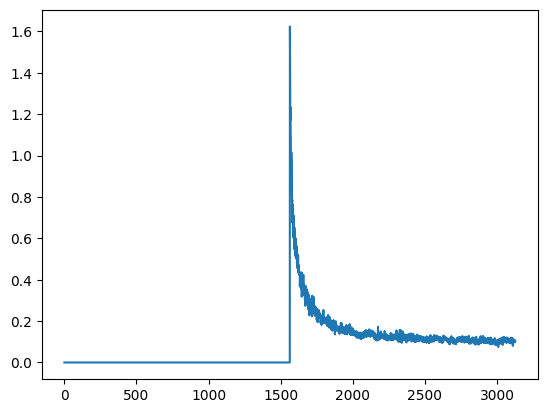

In [13]:
for i in range(0,1):

    model = Net()
    model.to(device)

    result = train_with_symmetry(model, trainloader, blurVF, symmetry_loss_weight=0.5, criterion_model=nn.CrossEntropyLoss(), n_epochs=4,
                    optimizer=optim.Adagrad, criterion_sym=nn.MSELoss(), lr=1e-2, nosymtime=0.5, mult=10*(32*32)**1)

    print(result[3])
    plt.plot(result[1])
    plt.show()

    with open('sym_losses' + str(i) + '.csv', 'w', newline='') as file:
        writer = csv.writer(file)
        for row in result[1]:
            writer.writerow([row])

    with open('sym_times' + str(i) + '.csv', 'w', newline='') as file:
        writer = csv.writer(file)
        for row in result[2]:
            writer.writerow([row])

    df = pd.DataFrame(result[3])
    df.to_csv("sym_accs" + str(i) + ".csv")

    torch.save(model.state_dict(), "sym_model" + str(i))